#**Exploratory Data Analysis using Visualization Assignment Answers**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('Titanic.csv')

In [4]:
print("--- First 5 Rows of the Dataset ---")
display(df.head())

--- First 5 Rows of the Dataset ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print("--- Missing Values Count Per Column ---")
print(df.isnull().sum())

--- Missing Values Count Per Column ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
# Impute missing 'Age' values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Cabin'] = df['Cabin'].fillna('Unknown')

print("\n--- Missing Values Count After Imputation ---")

print(df.isnull().sum())


--- Missing Values Count After Imputation ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


##**Assignment Questions (Visualization Based)**

**Q1.** Create a countplot to show the number of passengers by gender.

/tmp/ipykernel_4955/2878160186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='pastel')


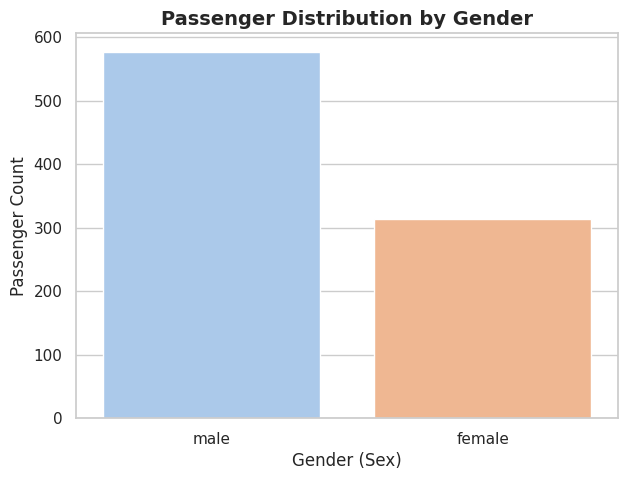

In [10]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Sex', palette='pastel')
plt.title('Passenger Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender (Sex)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.show()

**Interpretation:** The plot clearly demonstrates that there were significantly more male passengers on board than female passengers. Out of $891$ total recorded passengers, $577$ were male and $314$ were female.

**Q2.** Create a bar chart to show the number of passengers in each passenger class using different colors.

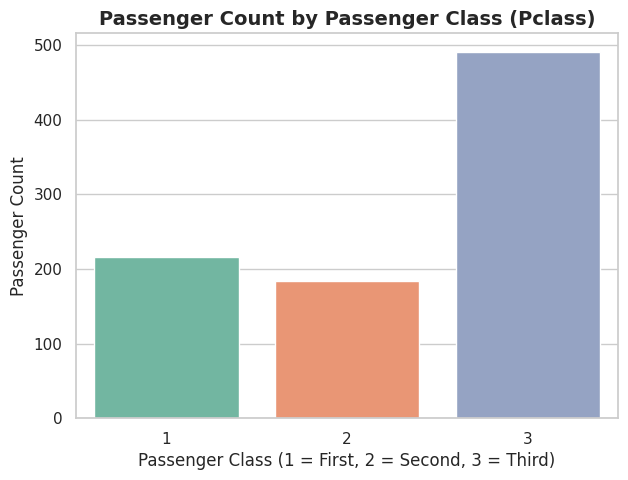

In [11]:
plt.figure(figsize=(7, 5))
# Using hue mapped to Pclass for individual bar coloring
sns.countplot(data=df, x='Pclass', hue='Pclass', palette='Set2', legend=False)
plt.title('Passenger Count by Passenger Class (Pclass)', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.show()

**Interpretation:** The bar chart shows that Third Class (Pclass 3) had the overwhelming majority of passengers with $491$ individuals, which is more than First Class ($216$) and Second Class ($184$) combined. This highlights that the majority of the passengers belonged to the lower economic tier.

**Q3.** Create a histogram to show the distribution of passenger age.

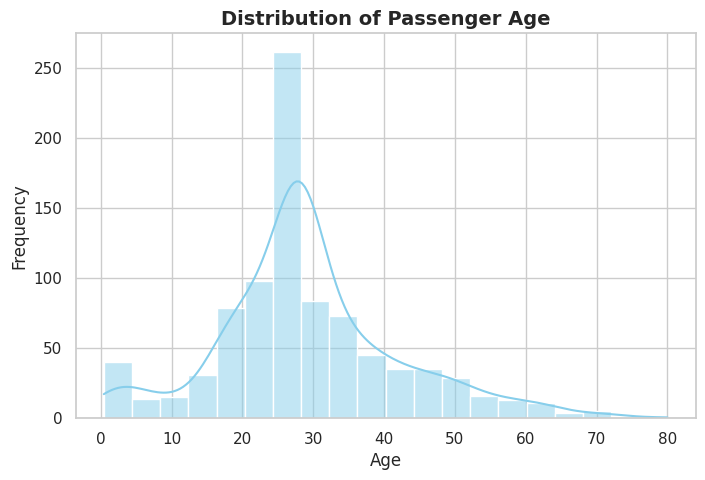

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Passenger Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

**Interpretation:** The age distribution is slightly right-skewed. A significant portion of the passengers were young adults aged between $20$ and $40$ years. There is also a small but notable spike at the far left, representing a substantial number of infants and young children ($0$ to $5$ years old) on board.

**Q4.** Create a boxplot to detect outliers in the fare column.

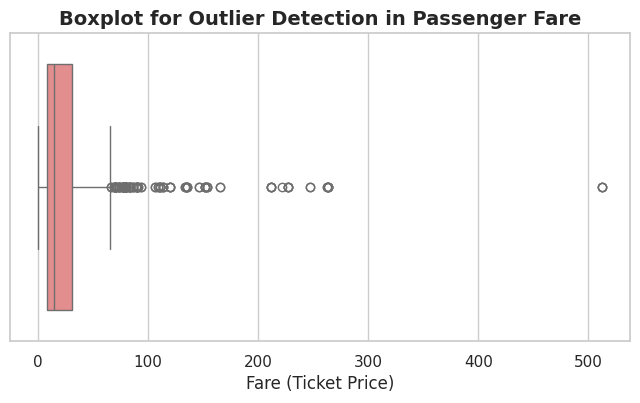

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Fare', color='lightcoral')
plt.title('Boxplot for Outlier Detection in Passenger Fare', fontsize=14, fontweight='bold')
plt.xlabel('Fare (Ticket Price)', fontsize=12)
plt.show()

**Interpretation:** The boxplot shows that the distribution of ticket fares is highly right-skewed. The median fare is quite low (around $\$14.45$), but there are numerous outliers stretching all the way to over $\$500$. These extreme outliers represent the ultra-wealthy individuals purchasing premium first-class suites.

**Q5.** Create a scatterplot to

 a. show the relationship between age and fare.

 b. analyze the relationship between family size (SibSp + Parch) and fare.

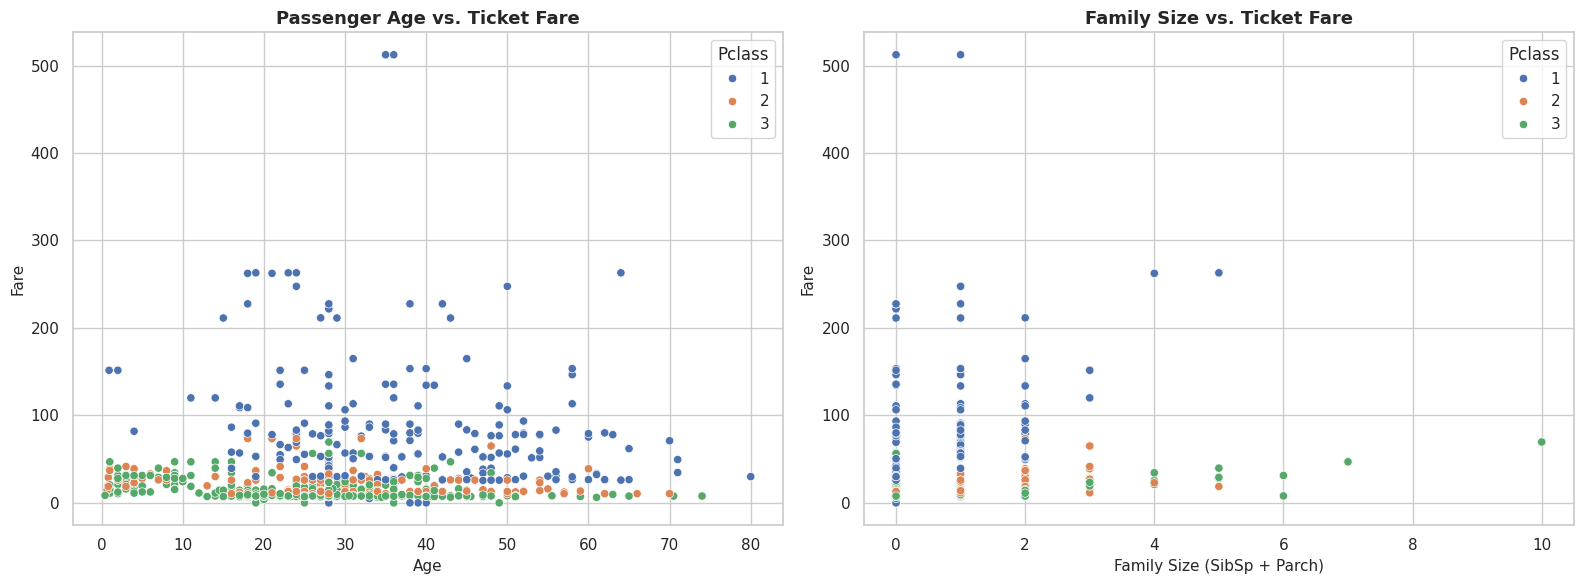

In [14]:
# Create Family Size column
df['FamilySize'] = df['SibSp'] + df['Parch']

# Set up a 1x2 subplot structure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 5a: Age vs Fare
sns.scatterplot(data=df, x='Age', y='Fare', hue='Pclass', palette='deep', ax=axes[0])
axes[0].set_title('Passenger Age vs. Ticket Fare', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=11)
axes[0].set_ylabel('Fare', fontsize=11)

# Subplot 5b: Family Size vs Fare
sns.scatterplot(data=df, x='FamilySize', y='Fare', hue='Pclass', palette='deep', ax=axes[1])
axes[1].set_title('Family Size vs. Ticket Fare', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Family Size (SibSp + Parch)', fontsize=11)
axes[1].set_ylabel('Fare', fontsize=11)

plt.tight_layout()
plt.show()

* **Interpretation for 5a:** There is no strong linear correlation between age and fare, as dots are scattered widely. However, the highest fares (above $\$100$) were paid exclusively by passengers in First Class (Pclass 1) regardless of their age group.
* **Interpretation for 5b:** Single passengers or small families (family size $1$ to $3$) paid a very wide distribution of fares, including all the highest luxury rates. On the other hand, large families (family size $\ge 4$) paid consistently low, uniform fares, indicating that large family groups traveled almost exclusively in Third Class.

**Q6.** Create a countplot to show survival count by gender.

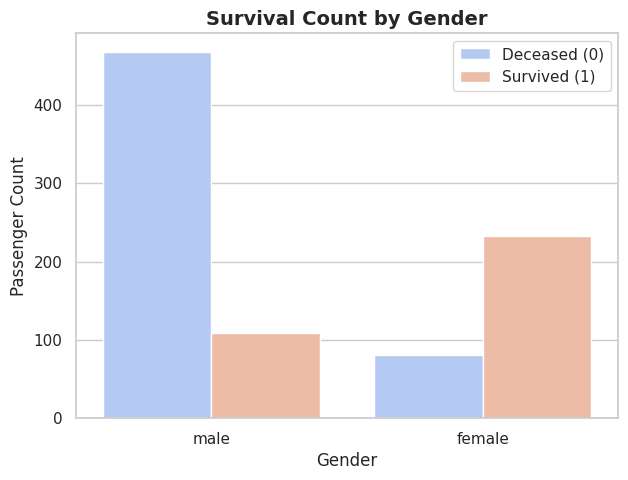

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Sex', hue='Survived', palette='coolwarm')
plt.title('Survival Count by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Passenger Count', fontsize=12)
plt.legend(['Deceased (0)', 'Survived (1)'], loc='upper right')
plt.show()

**Interpretation:** This visualization displays a striking difference in survival outcomes between genders. Even though males significantly outnumbered females on board, the vast majority of males perished ($468$ out of $577$), whereas the majority of females survived ($233$ out of $314$). This visually proves the historical execution of the "women and children first" safety protocol.

**Q7.** Create a bar chart to show survival by passenger class.

/tmp/ipykernel_4955/3483325432.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='viridis', errorbar=None)


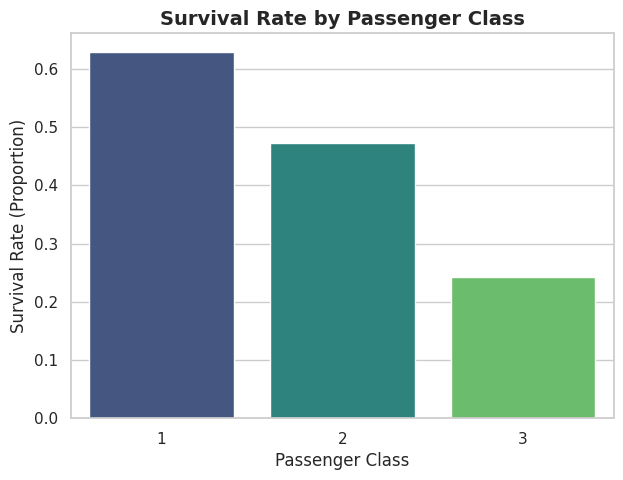

In [16]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Pclass', y='Survived', palette='viridis', errorbar=None)
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate (Proportion)', fontsize=12)
plt.show()

**Interpretation:** The bar chart depicts a strict socioeconomic gradient regarding survival. First-class passengers had the highest likelihood of survival (approx. $63\%$), followed by second-class passengers (approx. $47\%$), while third-class passengers had an extremely low survival rate (approx. $24\%$).

**Q8.** Create a heatmap to show correlation between numerical variables.

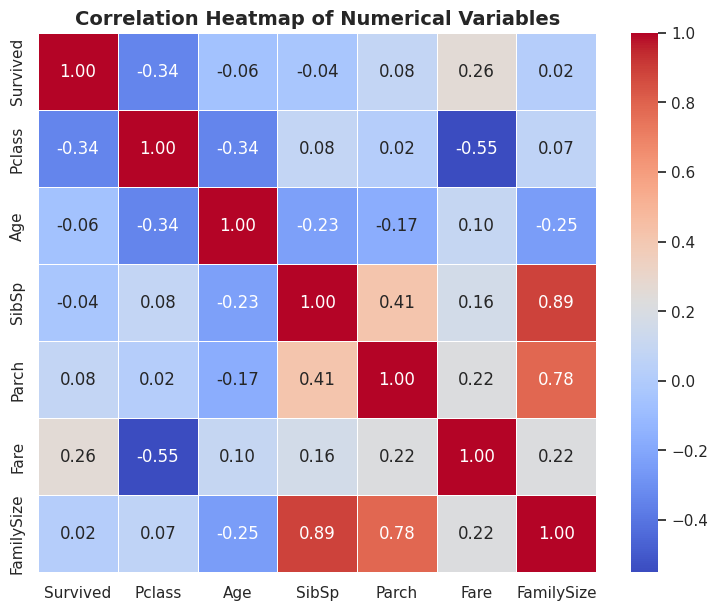

In [17]:
plt.figure(figsize=(9, 7))
# Select only relevant numerical columns
numerical_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']]
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')
plt.show()

**Interpretation:**  Pclass and Fare share a strong negative correlation ($-0.55$), establishing that lower class numbers ($1$st class) align with significantly higher ticket fares.
* Survived displays a moderate positive correlation with Fare ($0.26$) and a moderate negative correlation with Pclass ($-0.34$), verifying that wealthier individuals had higher structural survival rates.
* SibSp and Parch are strongly positively correlated with FamilySize because FamilySize is derived directly from them.

**Q9.** Identify which passenger class paid the highest fare on average.

In [18]:
# Compute the mean fare per passenger class
avg_fare_by_class = df.groupby('Pclass')['Fare'].mean().reset_index()
print("--- Average Fare by Passenger Class ---")
for index, row in avg_fare_by_class.iterrows():
    print(f"Passenger Class {int(row['Pclass'])}: ${row['Fare']:.2f}")

--- Average Fare by Passenger Class ---
Passenger Class 1: $84.15
Passenger Class 2: $20.66
Passenger Class 3: $13.68


**A9.** First Class (Pclass 1) paid the highest fare on average by a massive margin, with a mean price of $\$84.15$. In comparison, Second Class passengers paid an average of $\$20.66$ and Third Class passengers paid $\$13.68$.

**Q10.** Write at least 5 insights from the dataset based on your visualizations.


**A10.** Based on the data visualizations and exploratory data analysis, here are 5 key insights extracted from the Titanic dataset:
1. **The Gender Survival Gap:** Gender was the most significant factor in determining survival. Females had a survival rate of roughly $74.2\%$, while males had a survival rate of only $18.9\%$. This illustrates that evacuation efforts strictly prioritized women.
2. **Socioeconomic Priority:** A passenger's class directly influenced their survival chances. First-class passengers were almost three times more likely to survive ($62.9\%$) than third-class passengers ($24.2\%$), suggesting better proximity to lifeboats and prioritization during evacuation.
3. **Severe Wealth Inequality:** The ticket price structures demonstrate massive financial disparity. While the average ticket cost around $\$32.20$, the median was only $\$14.45$. The highest ticket fares extended above $\$500$, isolated entirely within First Class, showing a concentrated block of extreme luxury travelers.
4. **Demographic Concentration:** The demographic profile of the Titanic consisted largely of young adults between the ages of $20$ and $40$. Additionally, there was a visible population of infants and young toddlers who saw high rescue survival patterns.
5. **Family Size Constraints on Class:** Large families (composed of $5$ to $8+$ members) were entirely non-existent in the upper-class tiers. Larger families exclusively purchased lower-fare tickets in Third Class, indicating that traveling with large family units was a demographic trait confined primarily to working-class immigrants.